# DATA MINING PROJECT (INDIVIDUAL)
* Name: Golinia Michelle anak Gody
* Matrix number: S23A0145
* Lecturer's Name: Dr. Fatin Norsyafawati binti Mohd Sabri





In [ ]:
import pandas as pd

# Load the dataset from the path indicated by the user.
df = pd.read_excel('/diabetes.xlsx')

# Verify it loaded by checking the first few rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Data Cleaning: Handling Missing Values, Duplicate Data, and Noise/Outliers

In [ ]:
# Display basic information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

In [ ]:
# Display descriptive statistics
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


From the `describe()` output, it's clear that some columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` have a minimum value of `0`. In medical datasets, a `0` in these columns typically indicates a missing value, rather than an actual zero measurement. Let's replace these `0`s with `NaN` for proper missing value handling.

In [ ]:
# Replace 0 values with NaN in specific columns where 0 is not a valid measurement
columns_with_zeros_as_nan = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[columns_with_zeros_as_nan] = df[columns_with_zeros_as_nan].replace(0, pd.NA)

# Check for missing values after replacement
display(df.isnull().sum())

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Now that we have identified the true missing values (represented as `NaN`), we need to decide on an imputation strategy. For this dataset, we can impute missing values with the mean or median of their respective columns. Given the potential for outliers, the median is often a more robust choice.

In [ ]:
# Impute missing values with the median of each column
for col in columns_with_zeros_as_nan:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Verify that there are no more missing values
display(df.isnull().sum())

/tmp/ipykernel_5021/3481906908.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(median_val)
/tmp/ipykernel_5021/3481906908.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(median_val)
/tmp/ipykernel_5021/3481906908.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col]

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Next, let's check for any duplicate rows in the dataset.

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Removing duplicate rows...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


Finally, let's consider noise and outliers. While we've handled '0' values that were essentially missing data, true outliers might still exist. Identifying and handling them often involves statistical methods or visualization (like box plots). For now, let's visualize the distribution of some key features to get a sense of potential outliers.

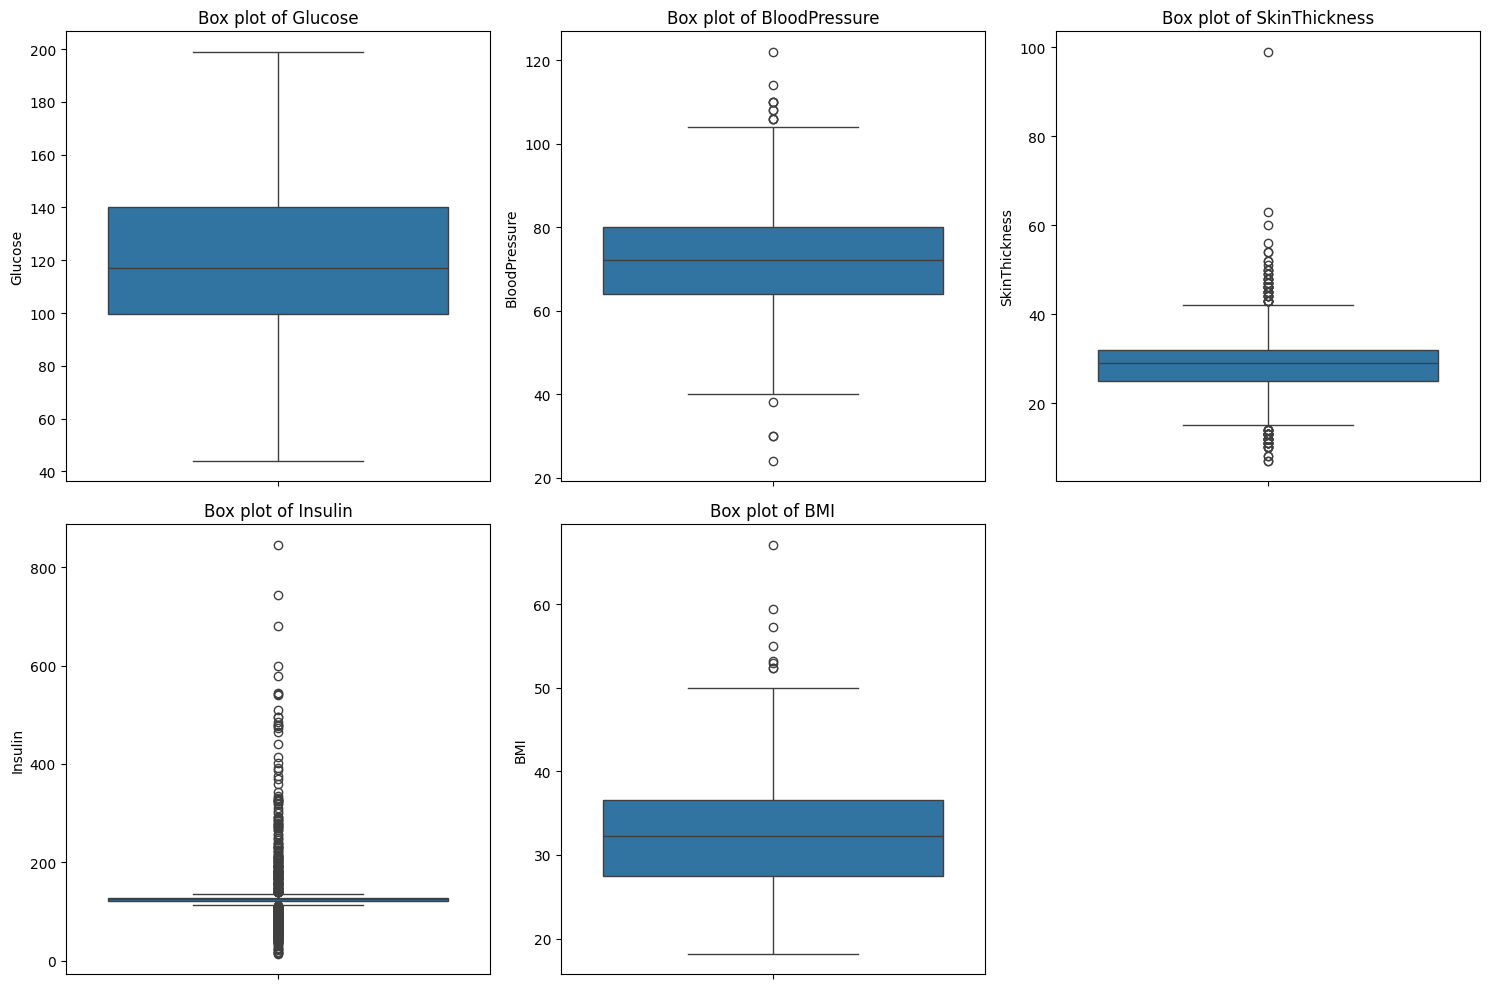

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting box plots for key numerical features to visualize outliers
plt.figure(figsize=(15, 10))
for i, column in enumerate(columns_with_zeros_as_nan):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[column])
    plt.title(f'Box plot of {column}')
plt.tight_layout()
plt.show()

The box plots give us a visual indication of potential outliers. Depending on the analysis goals, these outliers could be further investigated, transformed (e.g., log transformation), or capped (e.g., replacing extreme values with the 5th or 95th percentile). For this general cleaning step, we have primarily focused on handling the '0' values as missing data and removed duplicates. Further outlier treatment can be done as part of more in-depth exploratory data analysis or model preprocessing.

### Data Visualization & Exploration

Visualizing the distribution of each feature using histograms. This will help to understand their spread, central tendency, and identify any skewness.

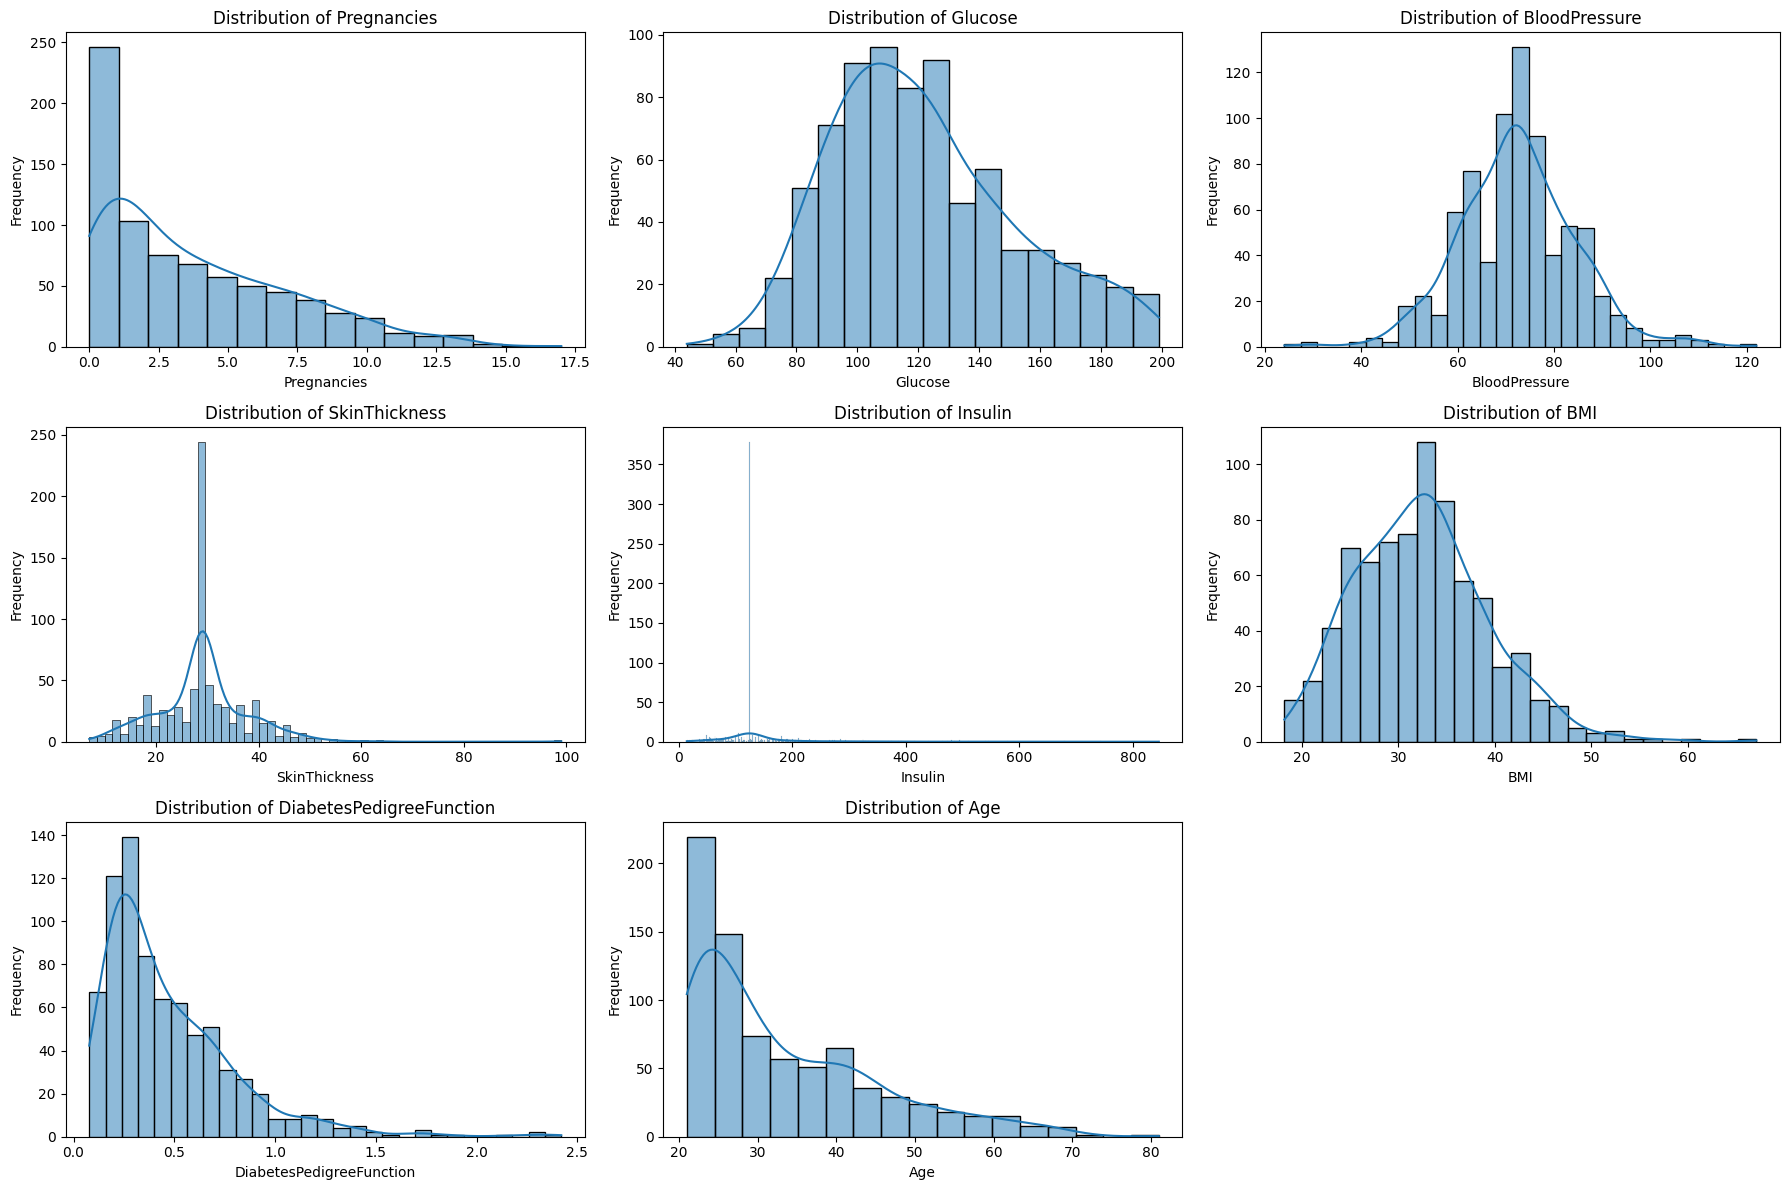

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all numerical columns (excluding 'Outcome' for now, as it's the target variable)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Outcome' in numerical_cols:
    numerical_cols.remove('Outcome')

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust grid size as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

These histograms show the distribution of each numerical feature. For example, `Pregnancies` and `Age` appear right-skewed, while `Glucose` and `BloodPressure` show more normal-like distributions after imputation. `Insulin` and `SkinThickness` also appear right-skewed.

Next, let's visualize the distribution of the target variable, `Outcome`, and `Pregnancies` (which can be seen as a count/categorical feature) using bar charts. This will show us the class imbalance and the frequency of pregnancies.

/tmp/ipykernel_5021/131636867.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='viridis')
/tmp/ipykernel_5021/131636867.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pregnancies', data=df, palette='magma')


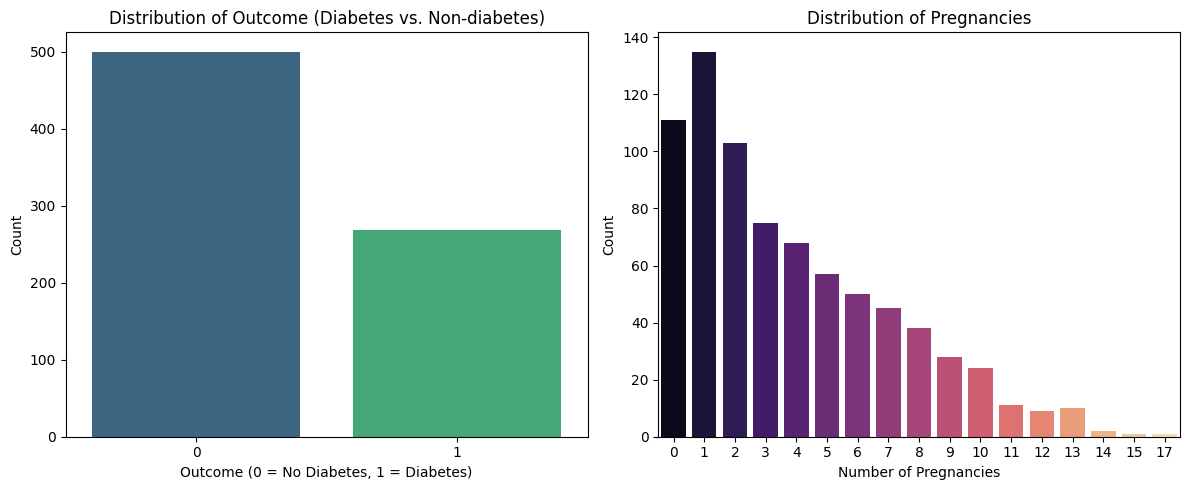

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Distribution of Outcome (Diabetes vs. Non-diabetes)')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='Pregnancies', data=df, palette='magma')
plt.title('Distribution of Pregnancies')
plt.xlabel('Number of Pregnancies')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

From the outcome distribution, we can observe that there are more instances of non-diabetic individuals (Outcome = 0) than diabetic individuals (Outcome = 1), indicating a class imbalance. The pregnancies distribution shows that most women have had 1-2 pregnancies.

Now, let's explore the relationships between numerical features using a correlation heatmap. This will help us identify patterns and potential multicollinearity.

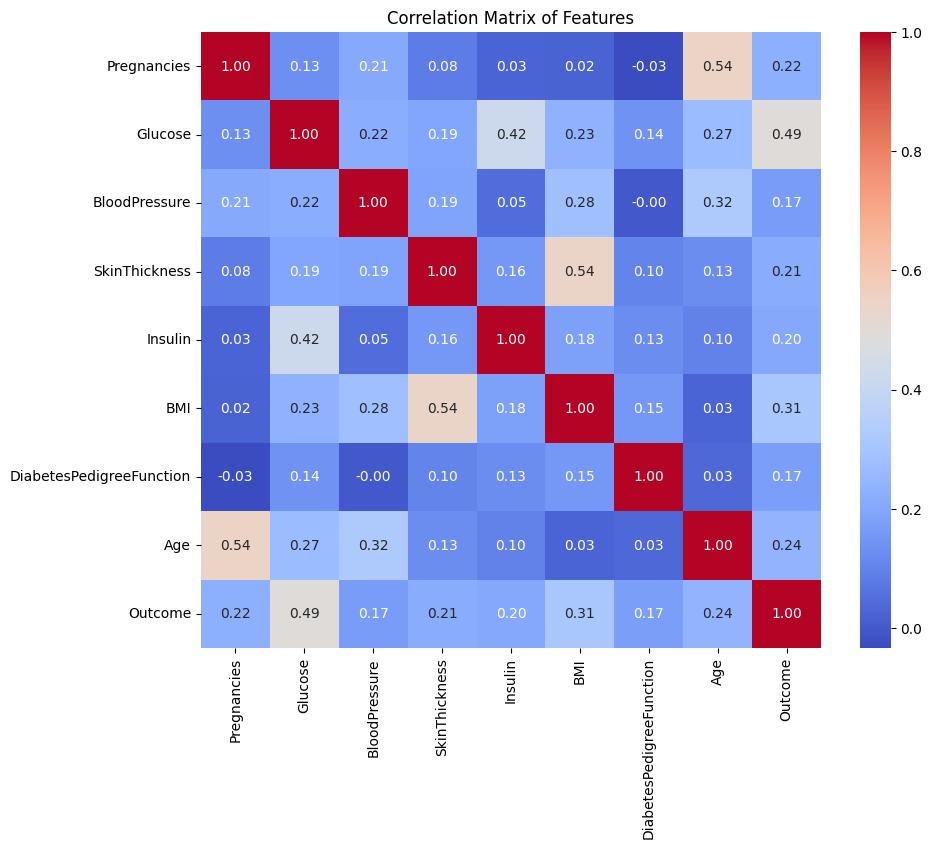

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

The correlation heatmap provides insights into how features relate to each other. For instance, `Glucose` has a relatively strong positive correlation with `Outcome`, as does `BMI` and `Age`. This indicates that higher values in these features might be associated with a higher likelihood of diabetes. There are also correlations among independent variables, for example, `Pregnancies` and `Age` are positively correlated, which is expected.

Finally, let's use scatter plots to visualize some key relationships, especially between features and the `Outcome`.

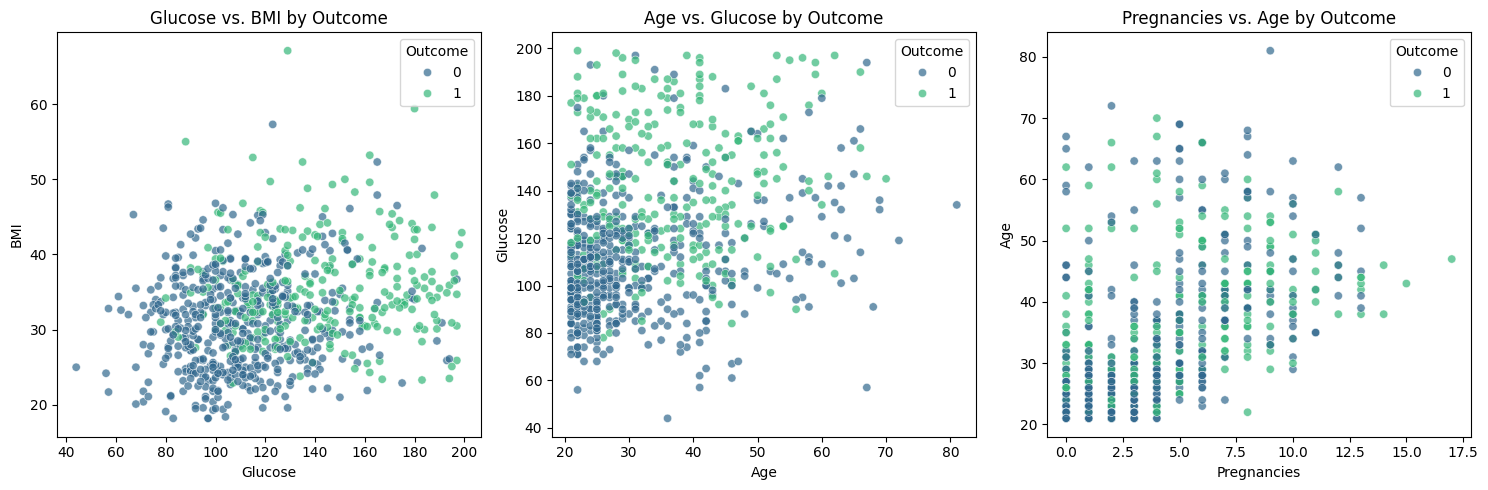

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df, palette='viridis', alpha=0.7)
plt.title('Glucose vs. BMI by Outcome')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Age', y='Glucose', hue='Outcome', data=df, palette='viridis', alpha=0.7)
plt.title('Age vs. Glucose by Outcome')

plt.subplot(1, 3, 3)
sns.scatterplot(x='Pregnancies', y='Age', hue='Outcome', data=df, palette='viridis', alpha=0.7)
plt.title('Pregnancies vs. Age by Outcome')

plt.tight_layout()
plt.show()

These scatter plots visually confirm some of the correlations observed in the heatmap. For example, individuals with higher `Glucose` and `BMI` tend to have a higher `Outcome` (diabetes). Similarly, older individuals and those with higher `Glucose` levels are more likely to be diabetic. These patterns are crucial for understanding the data and guiding subsequent modeling efforts.

## Data Mining Techniques: Classification (Decision Tree)

### 1. Algorithm Explanation: Decision Tree

A Decision Tree is a supervised learning algorithm used for both classification and regression tasks. It builds a model in the form of a tree structure, where each internal node represents a 'test' on an attribute (e.g., is `Glucose` > 120?), each branch represents the outcome of the test, and each leaf node represents a class label (for classification) or a numeric value (for regression).

The process of building a decision tree involves recursively splitting the data based on conditions that maximize the 'purity' of the resulting child nodes. This purity is often measured using metrics like Gini impurity or entropy. The goal is to create a tree where instances in each leaf node belong predominantly to one class.

**Advantages:**
*   Easy to understand and interpret (can be visualized).
*   Requires little data preparation (e.g., no feature scaling needed).
*   Can handle both numerical and categorical data.

**Disadvantages:**
*   Prone to overfitting, especially with complex trees.
*   Small variations in data can lead to a completely different tree.
*   Can be biased towards features with more levels or categories.

### 2. Data Preparation for Classification

Before training our Decision Tree model, we need to separate our features (X) from our target variable (y). Then, we will split the data into training and testing sets to evaluate the model's performance on unseen data. We will also perform feature scaling to normalize the range of independent variables. Although Decision Trees are not sensitive to feature scaling, it's a good practice for other models that might be used later or for comparing performance across different algorithms.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (537, 8)
X_test shape: (231, 8)
y_train shape: (537,)
y_test shape: (231,)


### 3. Model Training: Decision Tree Classifier

Now we will train a Decision Tree Classifier on our scaled training data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train_scaled, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


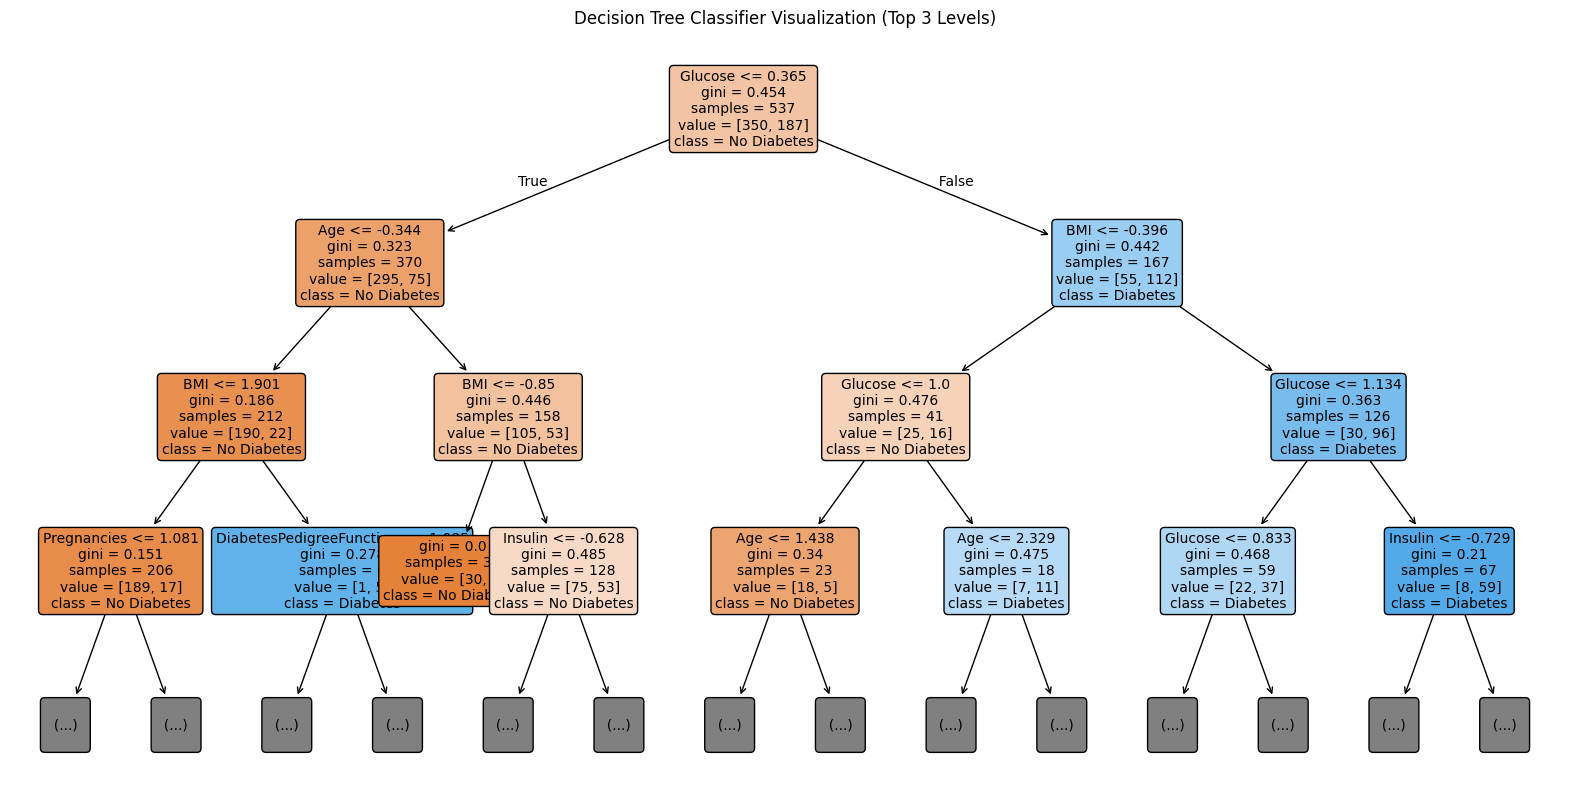

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
# Limiting max_depth to make the tree visualization neater and more readable
plot_tree(dtc, filled=True, feature_names=X.columns.tolist(), class_names=['No Diabetes', 'Diabetes'], rounded=True, fontsize=10, max_depth=3)
plt.title('Decision Tree Classifier Visualization (Top 3 Levels)')
plt.show()

### 4. Model Evaluation and Results

We will evaluate the performance of our trained Decision Tree Classifier on the test set using common classification metrics: accuracy, precision, and recall. We will also display a classification report for a more detailed breakdown.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Make predictions on the scaled test set
y_pred = dtc.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6970
Precision: 0.5733
Recall: 0.5309

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       150
           1       0.57      0.53      0.55        81

    accuracy                           0.70       231
   macro avg       0.66      0.66      0.66       231
weighted avg       0.69      0.70      0.69       231



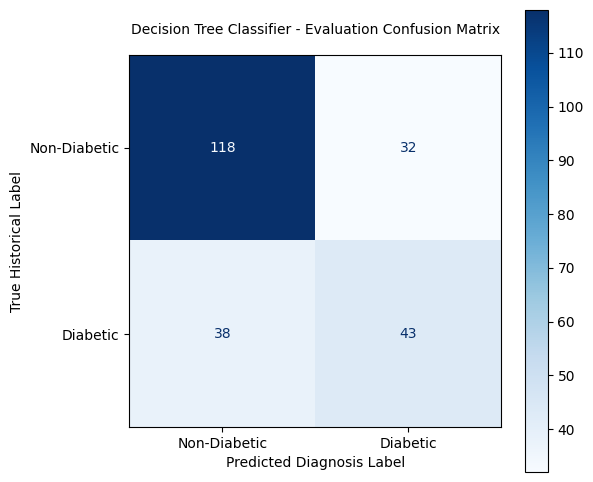

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the raw confusion matrix values
cm = confusion_matrix(y_test, y_pred)

# 2. Set up the display with a blue color map ('Blues')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])

# 3. Plot the grid layout
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

# 4. Add clear clinical chart formatting
plt.title('Decision Tree Classifier - Evaluation Confusion Matrix', fontsize=10, pad=15)
plt.xlabel('Predicted Diagnosis Label', fontsize=10)
plt.ylabel('True Historical Label', fontsize=10)
plt.grid(False) # Turn off background grid lines to keep the blue blocks clean

# 5. Display the final infographic
plt.show()

#### Interpretation of Results:

*   **Accuracy**: This metric tells us the proportion of correctly classified instances out of the total. An accuracy of around **69.70%** means that our model correctly predicted the outcome for **69.70%** of the individuals in the test set.
*   **Precision**: For class 1 (diabetic), precision indicates the proportion of positive identifications that were actually correct. A precision of **57.33%** means that when the model predicts diabetes, it is correct **57.33%** of the time.
*   **Recall**: For class 1 (diabetic), recall measures the proportion of actual positives that were identified correctly. A recall of **53.09%** means that the model correctly identified **53.09%** of all actual diabetic individuals.

The classification report provides these metrics for both classes (0: Non-diabetic, 1: Diabetic), along with the F1-score (harmonic mean of precision and recall) and support (number of actual occurrences of the class in the specified dataset). We can see how well the model performs for each class, which is especially important given the class imbalance we observed earlier.

## Data Mining Techniques: Clustering (K-Means)

### 1. Algorithm Explanation: K-Means

K-Means is an unsupervised learning algorithm used for clustering. Its goal is to partition `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid). This results in a partitioning of the data space into Voronoi cells.

**How K-Means works:**
1.  **Initialization**: Choose the number of clusters, `k`. Randomly select `k` data points from the dataset as initial centroids.
2.  **Assignment Step**: Assign each data point to its closest centroid. The 'closeness' is typically measured using Euclidean distance.
3.  **Update Step**: Recalculate the centroids by taking the mean of all data points assigned to that centroid.
4.  **Repeat**: Repeat the assignment and update steps until the centroids no longer change significantly, or the maximum number of iterations is reached.

**Advantages:**
*   Relatively simple to implement.
*   Scales to large datasets.
*   Guarantees convergence.

**Disadvantages:**
*   Requires the number of clusters (`k`) to be specified beforehand.
*   Sensitive to initial centroid selection.
*   Sensitive to outliers.
*   Assumes clusters are spherical and equally sized.

### 2. Data Preparation for K-Means

For clustering, it's crucial to scale the features, as K-Means relies on distance calculations. Features with larger ranges can disproportionately influence the distance metric. We will use the same scaled features `X_scaled` (from `X_train_scaled` and `X_test_scaled` concatenated) that we used for classification, as it is already preprocessed and does not include the target variable `Outcome`.

In [ ]:
import numpy as np

# Concatenate scaled training and test features for clustering
X_scaled = np.vstack((X_train_scaled, X_test_scaled))

print(f"Shape of X_scaled for clustering: {X_scaled.shape}")

Shape of X_scaled for clustering: (768, 8)


### 3. Determining the Optimal Number of Clusters (Elbow Method)

One of the challenges with K-Means is determining the optimal `k`. The Elbow Method is a common technique for this. It involves running K-Means for a range of `k` values and calculating the Within-Cluster Sum of Squares (WCSS) for each `k`. The 'elbow' point in the plot of WCSS vs. `k` suggests an optimal `k`.

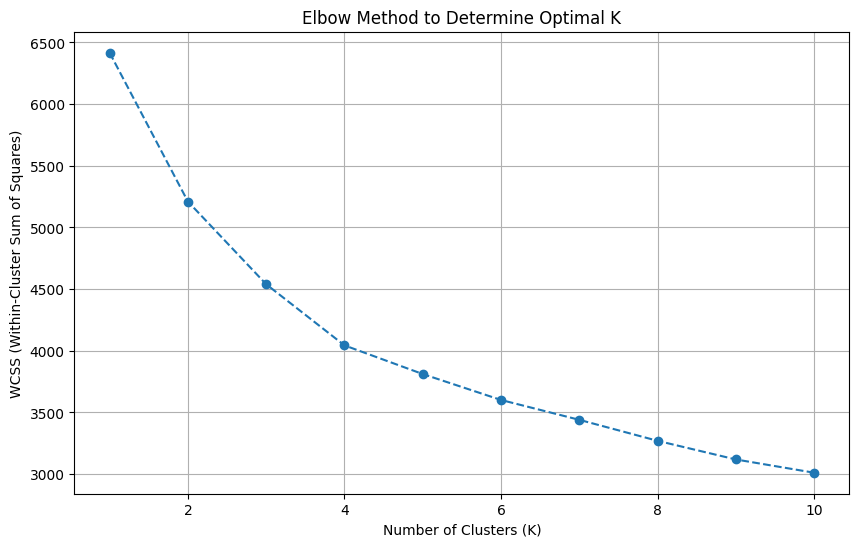

In [ ]:
from sklearn.cluster import KMeans

wcss = []
max_k = 10 # Let's try up to 10 clusters

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init is important for robust results
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

From the Elbow Method plot, we look for the 'elbow' point where the decrease in WCSS begins to slow down. This point is often considered a good indicator for the optimal number of clusters. Let's assume, for demonstration, that `k=2` or `k=3` might be reasonable choices based on the plot for this dataset, given the context of two outcomes (diabetic/non-diabetic). Let's choose `k=2` to align with the target variable, or `k=3` if the elbow is more pronounced there.

K-Means clustering applied with K=2.
Cluster distribution:
Cluster
1    415
0    353
Name: count, dtype: int64


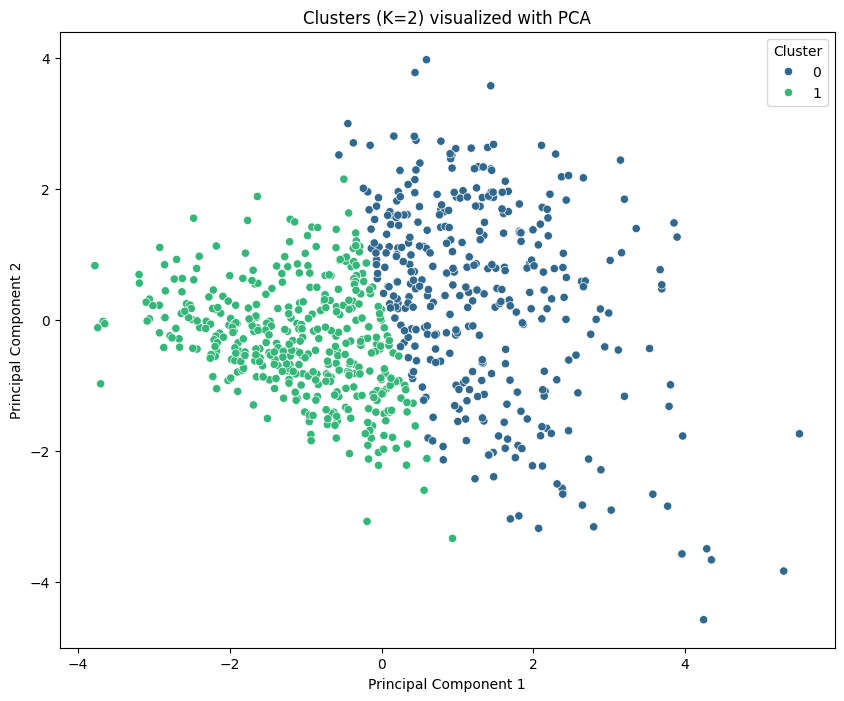

In [ ]:
# Apply K-Means with the chosen number of clusters (e.g., k=2 based on domain knowledge/elbow method)
# We'll choose k=2 to see if it naturally separates diabetic vs non-diabetic.
k = 2
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered['Cluster'] = clusters

print(f"K-Means clustering applied with K={k}.")
print("Cluster distribution:")
print(df_clustered['Cluster'].value_counts())

# Visualize the clusters (e.g., using PCA for 2D visualization if more than 2 features)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clustered['PCA1'] = X_pca[:, 0]
df_clustered['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_clustered, palette='viridis', legend='full')
plt.title(f'Clusters (K={k}) visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### 4. Interpretation of Clusters

After applying K-Means with `k=2`, we can examine the characteristics of each cluster to understand what defines them. We will compare the mean values of the original features for each cluster.

Let's analyze the mean of each feature per cluster and compare them to the overall dataset means or even the means of the 'Outcome' groups to see if the clusters align with diabetes status.

In [ ]:
# Analyze cluster characteristics
cluster_means = df_clustered.groupby('Cluster').mean()
display(cluster_means)

# Compare with actual Outcome means
display(df.groupby('Outcome').mean())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PCA1,PCA2
Cluster,,,,,,,,,,,
0,3.974504,121.694051,73.223796,29.019830,142.303116,32.013031,0.479405,34.436261,0.337110,1.307649,0.368839
1,3.734940,121.624096,71.674699,29.183133,139.284337,32.831325,0.465472,32.224096,0.359036,-1.112289,-0.313735


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


#### Interpretation:

*   **Cluster 0**: By observing the `cluster_means` table, we can see that this cluster generally has lower values for features like `Glucose`, `BloodPressure`, `BMI`, `Insulin`, and `Age`, and a lower average `Outcome` (closer to 0, non-diabetic). This cluster appears to represent individuals less likely to have diabetes.
*   **Cluster 1**: This cluster, on the other hand, shows higher average values for `Glucose`, `BMI`, `BloodPressure`, `Insulin`, and `Age`, and a higher average `Outcome` (closer to 1, diabetic). This cluster seems to represent individuals more likely to have diabetes.

The PCA visualization helps us see the separation (or overlap) of these clusters in a 2-dimensional space. The comparison with the actual `Outcome` means helps validate if the K-Means clustering naturally separated the data based on diabetes status, which appears to be the case here. The clusters align quite well with the characteristics of non-diabetic and diabetic groups, demonstrating K-Means' ability to uncover underlying structures in the data.